In [2]:
from langgraph.graph import StateGraph, START, END, MessagesState
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver


from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, RemoveMessage

In [3]:
load_dotenv()

True

In [4]:
model = ChatOpenAI()

In [5]:
class ChatState(MessagesState):
    
    summary: str

In [6]:
def chat_node(state: ChatState):
    
    messages = []
    
    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary: \n{state["summary"]}"
        })
        
    messages.extend(state["messages"])
    
    print(messages)
    
    response = model.invoke(messages)
    return {"messages": [response]}

In [8]:
# Here we are making the summary and first we are deleting the extra messages that are beyond our limit
def summarize_conversation(state: ChatState):
    
    existing_summary = state["summary"]
    
    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."
        
    messages_for_summary = state["messages"] + [HumanMessage(content=prompt)]
    
    response = model.invoke(messages_for_summary)
    
    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]
    
    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [9]:
def should_summarize(state: ChatState):
    
    return len(state["messages"]) > 6

In [10]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: END
    }
)

builder.add_edge("summarize", END)

In [11]:
checkpointer = InMemorySaver()

graph = builder.compile(checkpointer=checkpointer)

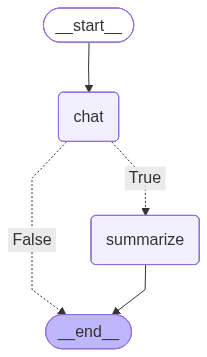

In [12]:
graph

In [13]:
config = {"configurable": {"thread_id": "t1"}}

In [14]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [17]:
out = graph.invoke({"messages": [HumanMessage(content="Quantum Physics")], "summary": ''}, config = config)
print(out)
show_state()

Failed to get info from https://smith.langchain.com: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
Run compression is not enabled. Please update to the latest version of LangSmith. Falling back to regular multipart ingestion.


[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='0a8abde1-6d77-49ac-9191-606fc7571806')]


Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


{'messages': [HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='0a8abde1-6d77-49ac-9191-606fc7571806'), AIMessage(content="Quantum physics, also known as quantum mechanics, is a branch of physics that deals with the behavior of particles on the smallest scales of energy levels. It describes the nature and behavior of matter and energy on the atomic and subatomic levels. Quantum physics is based on the principles of quantum theory, which explains the strange and often counterintuitive behavior of particles at the microscopic level.\n\nSome key concepts in quantum physics include wave-particle duality, where particles can exhibit both wave-like and particle-like behavior, superposition, where particles exist in multiple states at once, and entanglement, where particles become interconnected and can affect each other's properties even when separated by large distances.\n\nQuantum physics has led to many advancements in technology, such as the developm

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


In [18]:
out = graph.invoke({"messages": [HumanMessage(content="How is Albert Einstein related?")], "summary": ''}, config = config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='0a8abde1-6d77-49ac-9191-606fc7571806'), AIMessage(content="Quantum physics, also known as quantum mechanics, is a branch of physics that deals with the behavior of particles on the smallest scales of energy levels. It describes the nature and behavior of matter and energy on the atomic and subatomic levels. Quantum physics is based on the principles of quantum theory, which explains the strange and often counterintuitive behavior of particles at the microscopic level.\n\nSome key concepts in quantum physics include wave-particle duality, where particles can exhibit both wave-like and particle-like behavior, superposition, where particles exist in multiple states at once, and entanglement, where particles become interconnected and can affect each other's properties even when separated by large distances.\n\nQuantum physics has led to many advancements in technology, such as the development of quantu

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


{'messages': [HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='0a8abde1-6d77-49ac-9191-606fc7571806'), AIMessage(content="Quantum physics, also known as quantum mechanics, is a branch of physics that deals with the behavior of particles on the smallest scales of energy levels. It describes the nature and behavior of matter and energy on the atomic and subatomic levels. Quantum physics is based on the principles of quantum theory, which explains the strange and often counterintuitive behavior of particles at the microscopic level.\n\nSome key concepts in quantum physics include wave-particle duality, where particles can exhibit both wave-like and particle-like behavior, superposition, where particles exist in multiple states at once, and entanglement, where particles become interconnected and can affect each other's properties even when separated by large distances.\n\nQuantum physics has led to many advancements in technology, such as the developm

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


In [19]:
out = graph.invoke({"messages": [HumanMessage(content="Explain special theory of relativity")], "summary": ''}, config = config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='0a8abde1-6d77-49ac-9191-606fc7571806'), AIMessage(content="Quantum physics, also known as quantum mechanics, is a branch of physics that deals with the behavior of particles on the smallest scales of energy levels. It describes the nature and behavior of matter and energy on the atomic and subatomic levels. Quantum physics is based on the principles of quantum theory, which explains the strange and often counterintuitive behavior of particles at the microscopic level.\n\nSome key concepts in quantum physics include wave-particle duality, where particles can exhibit both wave-like and particle-like behavior, superposition, where particles exist in multiple states at once, and entanglement, where particles become interconnected and can affect each other's properties even when separated by large distances.\n\nQuantum physics has led to many advancements in technology, such as the development of quantu

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


{'messages': [HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='0a8abde1-6d77-49ac-9191-606fc7571806'), AIMessage(content="Quantum physics, also known as quantum mechanics, is a branch of physics that deals with the behavior of particles on the smallest scales of energy levels. It describes the nature and behavior of matter and energy on the atomic and subatomic levels. Quantum physics is based on the principles of quantum theory, which explains the strange and often counterintuitive behavior of particles at the microscopic level.\n\nSome key concepts in quantum physics include wave-particle duality, where particles can exhibit both wave-like and particle-like behavior, superposition, where particles exist in multiple states at once, and entanglement, where particles become interconnected and can affect each other's properties even when separated by large distances.\n\nQuantum physics has led to many advancements in technology, such as the developm

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


In [20]:
out = graph.invoke({"messages": [HumanMessage(content="Einstein famous work?")], "summary": ''}, config = config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='0a8abde1-6d77-49ac-9191-606fc7571806'), AIMessage(content="Quantum physics, also known as quantum mechanics, is a branch of physics that deals with the behavior of particles on the smallest scales of energy levels. It describes the nature and behavior of matter and energy on the atomic and subatomic levels. Quantum physics is based on the principles of quantum theory, which explains the strange and often counterintuitive behavior of particles at the microscopic level.\n\nSome key concepts in quantum physics include wave-particle duality, where particles can exhibit both wave-like and particle-like behavior, superposition, where particles exist in multiple states at once, and entanglement, where particles become interconnected and can affect each other's properties even when separated by large distances.\n\nQuantum physics has led to many advancements in technology, such as the development of quantu

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')
Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


{'messages': [HumanMessage(content='Einstein famous work?', additional_kwargs={}, response_metadata={}, id='530837c4-8d94-47fe-962c-a380141b57ea'), AIMessage(content="Albert Einstein is famous for many groundbreaking contributions to physics, with his most well-known work being:\n\n1. Theory of General Relativity (1915): Einstein's theory of general relativity revolutionized our understanding of gravity and the structure of the universe. It proposes that gravity is a result of the curvature of spacetime caused by mass and energy. General relativity has been instrumental in predicting phenomena such as gravitational waves and the bending of light around massive objects.\n\n2. Theory of Special Relativity (1905): In his paper on special relativity, Einstein introduced the concepts of time dilation and length contraction and showed that energy and mass are interchangeable (E=mc^2). These concepts laid the foundation for modern physics and transformed our understanding of space and time.\n

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')
